In [1]:
import json
import os
from glob import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%config InlineBackend.figure_format='retina'

In [2]:
# Find subfolders in evals/manuscripts/*/v1/ that contain all 4 JSON files
base_path = "manuscripts"
manuscript_dirs = []
for manuscript_id in os.listdir(base_path):
    v1_path = os.path.join(base_path, manuscript_id, "v1")
    if not os.path.isdir(v1_path):
        continue
    required_files = ["eval_llm.json", "eval_peer.json", "cmp.json", "claims.json"]
    all_present = all(os.path.exists(os.path.join(v1_path, fname)) for fname in required_files)
    if all_present:
        manuscript_dirs.append((manuscript_id, v1_path))

# Will concatenate all dfs from all manuscripts
dfs_llm = []
dfs_peer = []
dfs_cmp = []
dfs_claims = []
for manuscript_id, v1_path in manuscript_dirs:
    with open(os.path.join(v1_path, "eval_llm.json"), "r") as f:
        eval_llm = json.load(f)
    with open(os.path.join(v1_path, "eval_peer.json"), "r") as f:
        eval_peer = json.load(f)
    with open(os.path.join(v1_path, "cmp.json"), "r") as f:
        cmp = json.load(f)
    with open(os.path.join(v1_path, "claims.json"), "r") as f:
        claims = json.load(f)
    df_llm = pd.DataFrame(eval_llm)
    df_peer = pd.DataFrame(eval_peer)
    df_cmp = pd.DataFrame(cmp)
    df_claims = pd.DataFrame(claims)
    # Add manuscript_id as a column for possible stratification
    for df in (df_llm, df_peer, df_cmp, df_claims):
        df["manuscript_id"] = manuscript_id
    dfs_llm.append(df_llm)
    dfs_peer.append(df_peer)
    dfs_cmp.append(df_cmp)
    dfs_claims.append(df_claims)

# Concatenate
df_llm = pd.concat(dfs_llm, ignore_index=True)
df_peer = pd.concat(dfs_peer, ignore_index=True)
df_cmp = pd.concat(dfs_cmp, ignore_index=True)
df_claims = pd.concat(dfs_claims, ignore_index=True)

In [3]:
df_cmp["peer_status"] = df_cmp["peer_status"].fillna("Unknown").replace("Unknown", "Not reviewed")
df_cmp["llm_status"] = df_cmp["llm_status"].fillna("Unknown").replace("Unknown", "Not reviewed")

ordered_statuses = ["Supported", "Uncertain", "Unsupported", "Not reviewed"]

df_cmp["peer_status"] = df_cmp["peer_status"].astype(str).str.capitalize()
df_cmp["llm_status"] = df_cmp["llm_status"].astype(str).str.capitalize()
df_cmp["peer_status"] = pd.Categorical(df_cmp["peer_status"], categories=ordered_statuses, ordered=True)
df_cmp["llm_status"] = pd.Categorical(df_cmp["llm_status"], categories=ordered_statuses, ordered=True)

/var/folders/sc/mhzvj87n1cbgbl577pc9gc9r0000gn/T/ipykernel_26490/312984096.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_agree.set_yticklabels(ax_agree.get_yticks(), fontsize=fontsize)


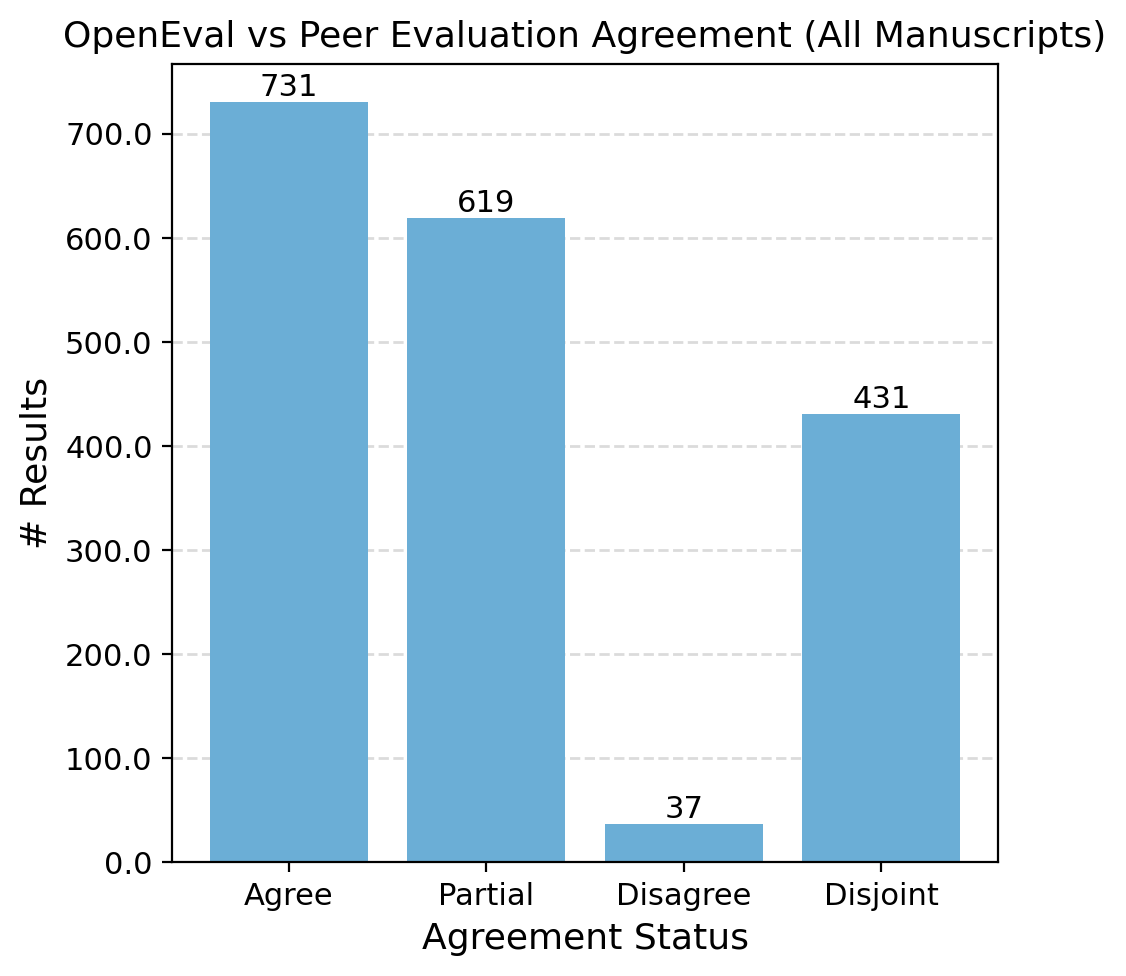

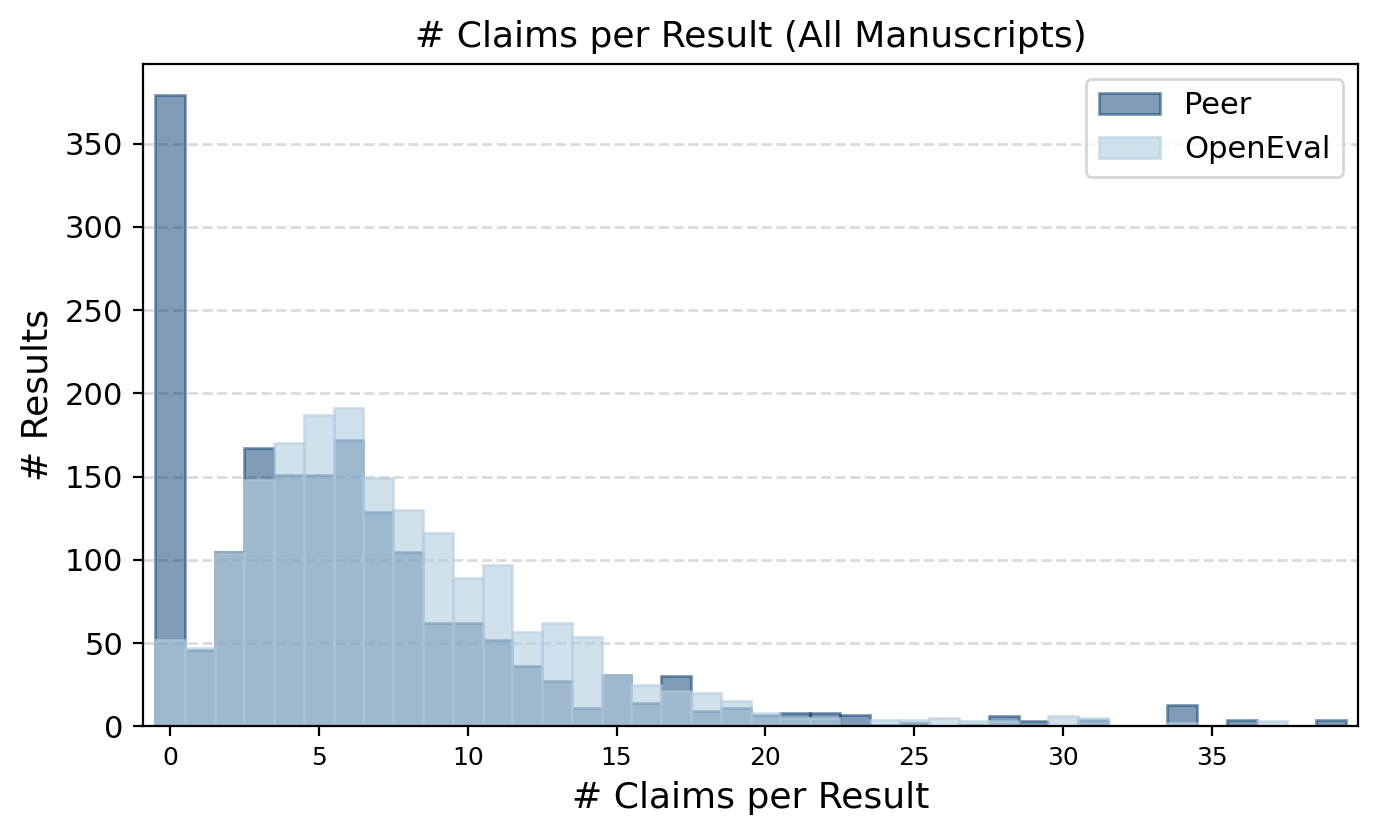

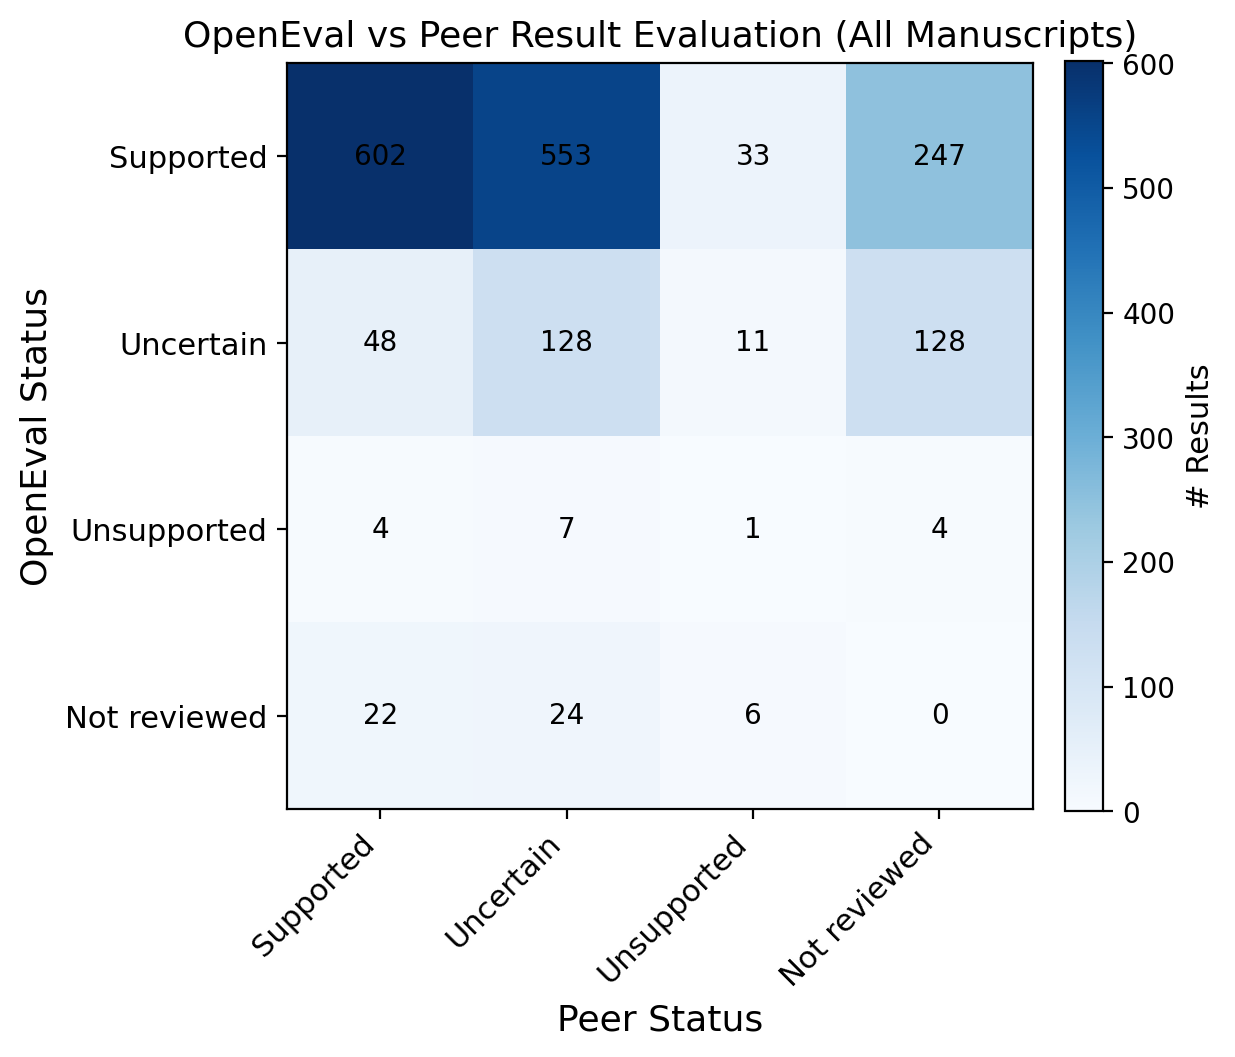

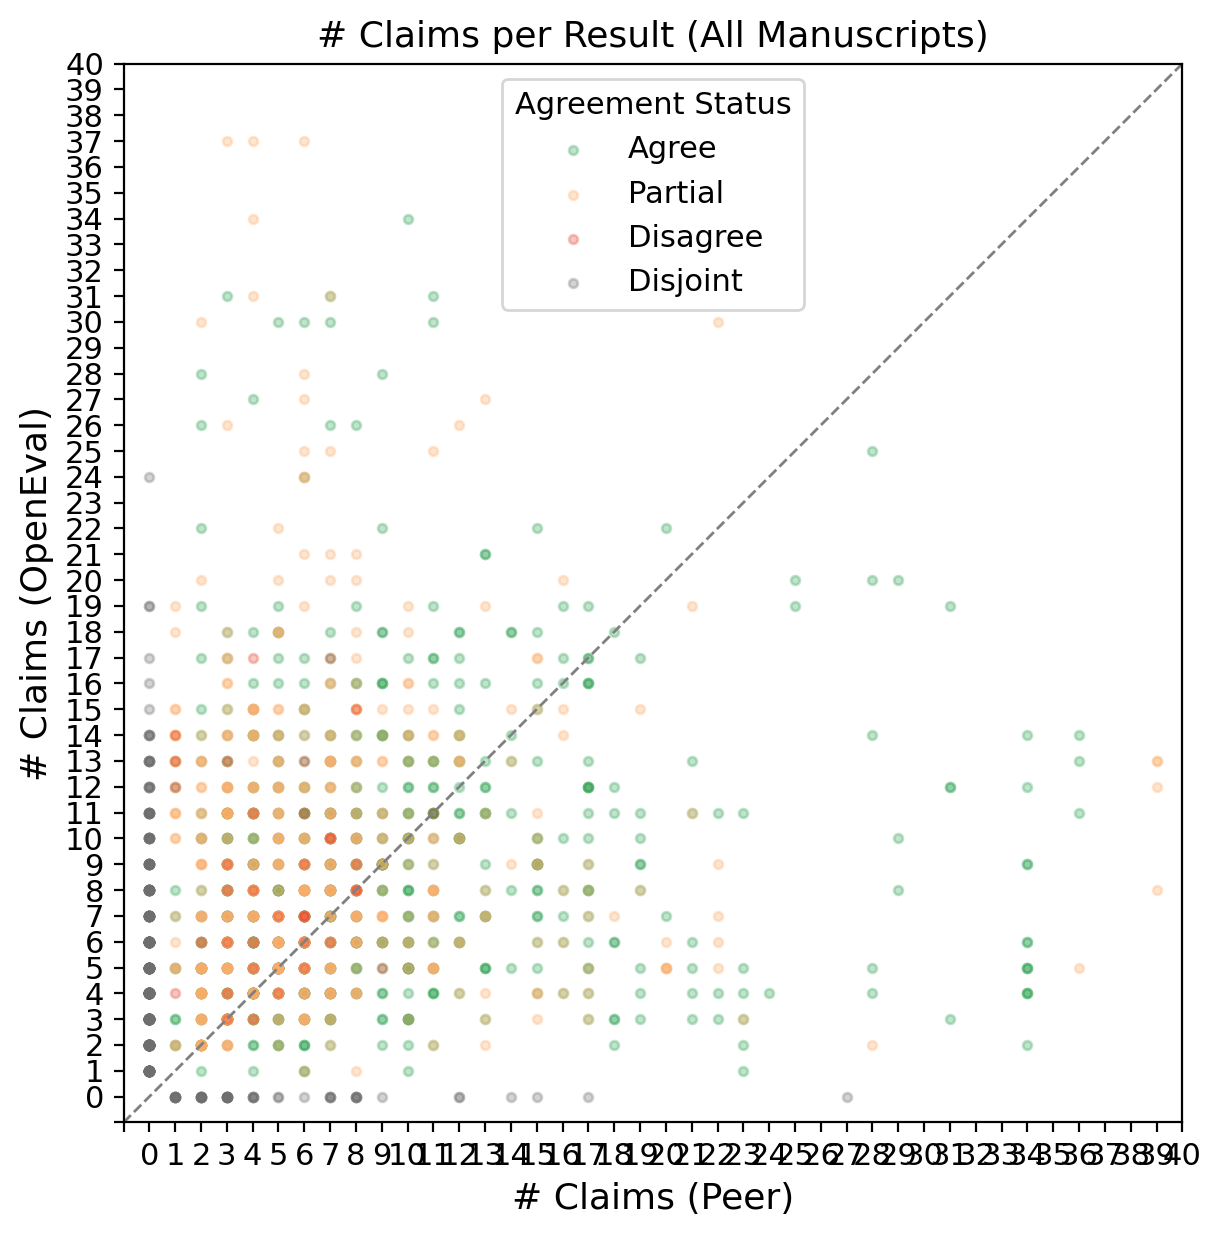

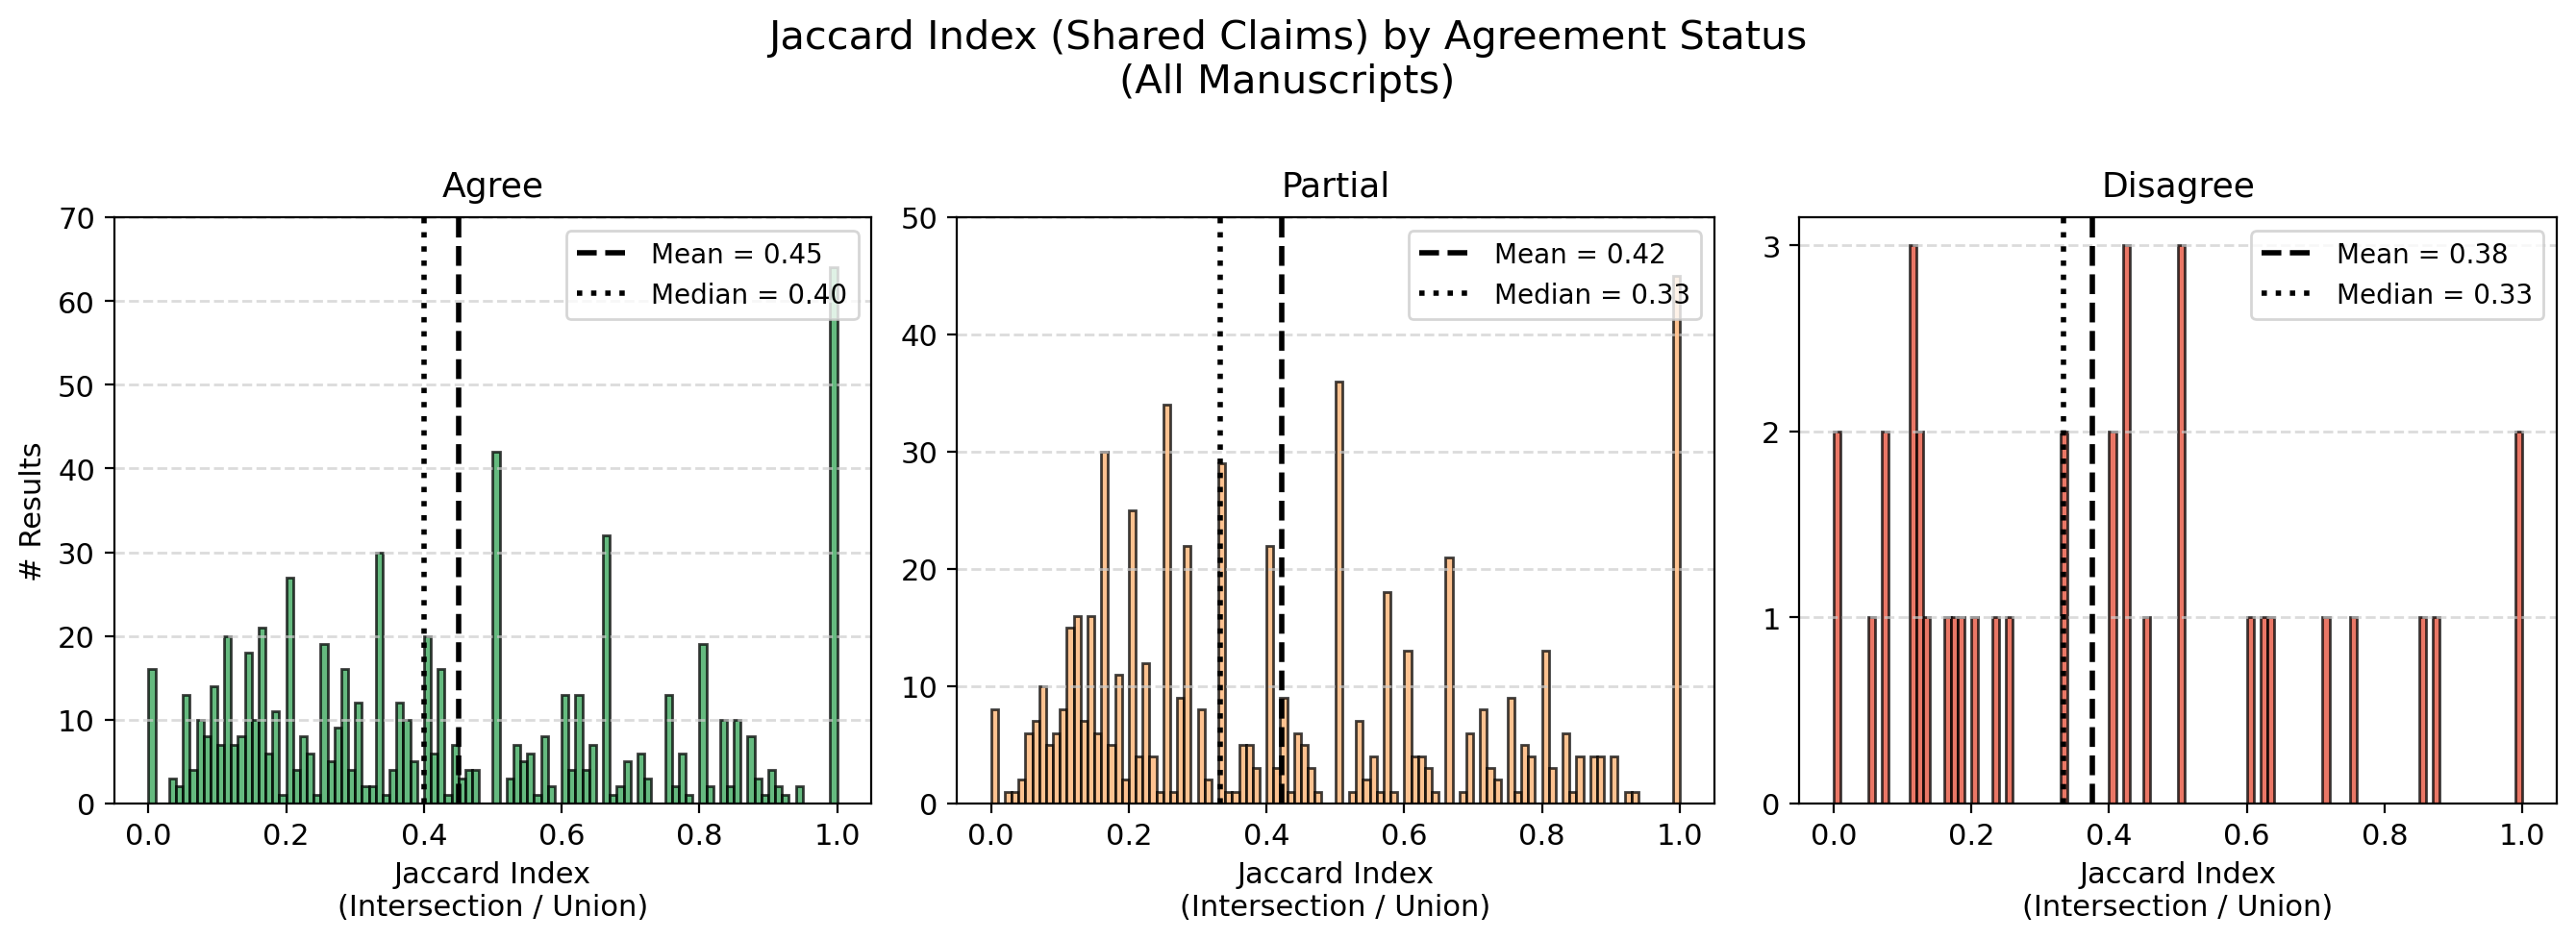


Summary statistics (all manuscripts):


,n_results,n_llm,n_peer,n_itx,intersection_fraction
agreement_status,,,,,
Agree,731,8.63,8.77,4.33,0.45
Partial,619,8.95,6.70,3.76,0.42
Disagree,37,8.57,5.03,2.76,0.38
Disjoint,379,4.93,5.13,0.00,0.00


In [31]:
# --- Plotting and color configs ---
bar_color = "#6baed6"

colors = {
    "Agree": "#31a354",
    "Partial": "#fdae6b",
    "Disagree": "#e34a33",
    "Disjoint": "#6e6e6e"
}
status_colors = colors

colors_stacked = {
    "shared": "#6497b1",
    "llm_only": "#b3cde0",
    "peer_only": "#03396c"
}
jaccard_color = "#6497b1"

fontsize = 11

# Proper agreement category order and capitalization
desired_agree_order = ["Agree", "Partial", "Disagree", "Disjoint"]

df_cmp["agreement_status"] = df_cmp["agreement_status"].astype(str).str.capitalize()

# Calculate intersection fraction (Jaccard denominator is max(n_llm, n_peer))
df_cmp["intersection_fraction"] = df_cmp["n_itx"] / df_cmp[["n_llm", "n_peer"]].max(axis=1)

def safe_int(s):
    return s.where(pd.notnull(s) & np.isfinite(s), 0).astype(int)

df_cmp["n_peer_int"] = safe_int(df_cmp["n_peer"])
df_cmp["n_llm_int"] = safe_int(df_cmp["n_llm"])

# --- 1. Bar plot: agreement status count ---
fig_agree, ax_agree = plt.subplots(figsize=(5.2, 5))
agreement_counts = df_cmp["agreement_status"].value_counts()
agreement_counts = agreement_counts.reindex(desired_agree_order, fill_value=0)
ax_agree.bar(agreement_counts.index, agreement_counts.values, color=bar_color)
ax_agree.grid(axis='y', linestyle="--", color="#cccccc", linewidth=1, alpha=0.7, zorder=0)
ax_agree.set_axisbelow(True)
ax_agree.set_title("OpenEval vs Peer Evaluation Agreement (All Manuscripts)", fontsize=fontsize+2)
ax_agree.set_xlabel("Agreement Status", fontsize=fontsize+2)
ax_agree.set_ylabel("# Results", fontsize=fontsize+2)
ax_agree.set_xticks(range(len(desired_agree_order)))
ax_agree.set_xticklabels(agreement_counts.index, fontsize=fontsize)
ax_agree.set_yticklabels(ax_agree.get_yticks(), fontsize=fontsize)
for i, val in enumerate(agreement_counts.values):
    ax_agree.text(i, val + 0.05, str(val), ha="center", va="bottom", fontsize=fontsize)
plt.tight_layout()
fig_agree.savefig("figures/eval_agreement_bar_all.png", dpi=300, bbox_inches='tight')
plt.show()

# --- 1b. Histogram of # claims per result for LLM and Peer, excluding Disjoint ---
# Filter out 'Disjoint' agreement results (or not)
# df_cmp_no_disjoint = df_cmp[df_cmp["agreement_status"] != "Disjoint"]
df_cmp_no_disjoint = df_cmp.copy()

bins_claims = np.arange(
    0,
    max(df_cmp_no_disjoint["n_llm_int"].max(), df_cmp_no_disjoint["n_peer_int"].max()) + 2
) - 0.5  # Center bins on integers

fig_claim_hist, ax_claim_hist = plt.subplots(figsize=(7, 4.3))
ax_claim_hist.hist(
    df_cmp_no_disjoint["n_peer_int"],
    bins=bins_claims,
    alpha=0.5,
    label="Peer",
    color=colors_stacked["peer_only"],
    edgecolor=colors_stacked["peer_only"]
)
ax_claim_hist.hist(
    df_cmp_no_disjoint["n_llm_int"],
    bins=bins_claims,
    alpha=0.6,
    label="OpenEval",
    color=colors_stacked["llm_only"],
    edgecolor=colors_stacked["llm_only"]
)
ax_claim_hist.set_title("# Claims per Result (All Manuscripts)", fontsize=fontsize+2)
ax_claim_hist.set_xlabel("# Claims per Result", fontsize=fontsize+2)
ax_claim_hist.set_ylabel("# Results", fontsize=fontsize+2)
ax_claim_hist.legend(fontsize=fontsize, title_fontsize=fontsize)
ax_claim_hist.margins(x=0.01)
ax_claim_hist.tick_params(axis='x', labelsize=fontsize-2)
ax_claim_hist.tick_params(axis='y', labelsize=fontsize)
ax_claim_hist.grid(axis='y', linestyle="--", color="#cccccc", linewidth=1, alpha=0.7, zorder=0)
ax_claim_hist.set_axisbelow(True)
plt.tight_layout()
fig_claim_hist.savefig("figures/claims_per_result_histogram_all_no_disjoint.png", dpi=300, bbox_inches="tight")
plt.show()

# --- 2. Confusion Matrix: Peer vs LLM result status ---
fig_conf, ax_conf = plt.subplots(figsize=(6.3, 6.3))
conf_mat = pd.crosstab(df_cmp["peer_status"], df_cmp["llm_status"]).reindex(
    index=ordered_statuses, columns=ordered_statuses, fill_value=0
)
im = ax_conf.imshow(conf_mat.T, cmap="Blues", aspect="equal")
ax_conf.set_title("OpenEval vs Peer Result Evaluation (All Manuscripts)", fontsize=fontsize+2)
ax_conf.set_xlabel("Peer Status", fontsize=fontsize+2)
ax_conf.set_ylabel("OpenEval Status", fontsize=fontsize+2)
ax_conf.set_xticks(range(len(ordered_statuses)))
ax_conf.set_yticks(range(len(ordered_statuses)))
ax_conf.set_xticklabels(ordered_statuses, rotation=45, ha="right", fontsize=fontsize)
ax_conf.set_yticklabels(ordered_statuses, fontsize=fontsize)
for i in range(len(ordered_statuses)):
    for j in range(len(ordered_statuses)):
        ax_conf.text(j, i, conf_mat.iloc[j, i], ha="center", va="center", color="black", fontsize=10)
cbar = fig_conf.colorbar(im, ax=ax_conf, fraction=0.046, pad=0.04)
cbar.set_label("# Results", fontsize=fontsize)
ax_conf.set_aspect('equal', adjustable='box')
plt.tight_layout()
fig_conf.savefig("figures/evals_confusion_matrix_all.png", dpi=300, bbox_inches='tight')
plt.show()

# --- 3. Scatter plot: claims per result (color by agreement) ---
fig_scatter, ax_scatter = plt.subplots(figsize=(6.3, 6.3))
# ax_scatter.grid(axis='both', linestyle="--", color="#cccccc", linewidth=1, alpha=0.7, zorder=0)
# ax_scatter.set_axisbelow(True)
for status in desired_agree_order:
    group = df_cmp[df_cmp["agreement_status"] == status]
    if not group.empty:
        ax_scatter.scatter(
            group["n_peer_int"], group["n_llm_int"], s=10,
            label=status, color=colors.get(status, "gray"),
            alpha=0.3
        )
        # # Label with manuscript id and IDs
        # for _, row in group.iterrows():
        #     label_str = f"{row['manuscript_id']}:{row['llm_result_id']}/{row['peer_result_id']}"
        #     ax_scatter.text(row["n_peer_int"] + 0.2, row["n_llm_int"] + 0.2, label_str, fontsize=7)
min_val = min(df_cmp["n_peer_int"].min(), df_cmp["n_llm_int"].min())
max_val = max(df_cmp["n_peer_int"].max(), df_cmp["n_llm_int"].max())
xlim = (-1, max_val + 1)
ylim = (-1, max_val + 1)
ax_scatter.set_xlim(xlim)
ax_scatter.set_ylim(ylim)
ax_scatter.set_aspect('equal', adjustable='box')
line_min = min(xlim[0], ylim[0])
line_max = max(xlim[1], ylim[1])
ax_scatter.plot([line_min, line_max], [line_min, line_max], "--", color="gray", lw=1, zorder=1)
ax_scatter.set_title("# Claims per Result (All Manuscripts)", fontsize=fontsize+2)
ax_scatter.set_xlabel("# Claims (Peer)", fontsize=fontsize+2)
ax_scatter.set_ylabel("# Claims (OpenEval)", fontsize=fontsize+2)
xticks = yticks = range(int(line_min), int(line_max) + 1)

def hide_minus1_ticklabels(ticks):
    return ['' if str(tick) == '-1' else str(tick) for tick in ticks]

ax_scatter.set_xticks(xticks)
ax_scatter.set_yticks(yticks)
ax_scatter.set_xticklabels(hide_minus1_ticklabels(xticks), fontsize=fontsize)
ax_scatter.set_yticklabels(hide_minus1_ticklabels(yticks), fontsize=fontsize)
ax_scatter.legend(title="Agreement Status", fontsize=fontsize, title_fontsize=fontsize, loc="best")
plt.tight_layout()
fig_scatter.savefig("figures/claims_per_result_scatter_all.png", dpi=300, bbox_inches='tight')
plt.show()

# # --- 4. Combined stacked bar and Jaccard index plot (shared x-axis) ---
# # Prepare values for stacked & Jaccard bar charts
# mask = (~df_cmp["n_peer"].isna()) & (~df_cmp["n_llm"].isna())
# df_overlap = df_cmp[mask].reset_index(drop=True)

# sort_agree = desired_agree_order
# def sort_key(row):
#     status = str(row["agreement_status"]).capitalize()
#     order = sort_agree.index(status) if status in sort_agree else 99
#     jaccard = row["intersection_fraction"] if not pd.isnull(row["intersection_fraction"]) else 0
#     return (order, -jaccard)

# if "agreement_status" in df_overlap.columns and "intersection_fraction" in df_overlap.columns:
#     df_overlap = df_overlap.copy()
#     df_overlap["agreement_status"] = df_overlap["agreement_status"].astype(str).str.capitalize()
#     df_overlap["__sort__"] = df_overlap.apply(sort_key, axis=1)
#     df_overlap = df_overlap.sort_values("__sort__").reset_index(drop=True)
#     df_overlap = df_overlap.drop(columns="__sort__")

# df_overlap["n_llm_only"] = df_overlap["n_llm"] - df_overlap["n_itx"]
# df_overlap["n_peer_only"] = df_overlap["n_peer"] - df_overlap["n_itx"]
# df_overlap["n_shared"] = df_overlap["n_itx"]
# df_overlap["jaccard"] = df_overlap["intersection_fraction"]
# llm_only_counts = df_overlap["n_llm_only"].values
# peer_only_counts = df_overlap["n_peer_only"].values
# shared_counts = df_overlap["n_shared"].values
# jaccard_vals = df_overlap["jaccard"].values
# bar_width = 0.85
# indices = np.arange(len(df_overlap))

# if ("llm_result_id" in df_overlap.columns) and ("peer_result_id" in df_overlap.columns):
#     xtick_labels = [
#         f"{m_id}:{llm_id}/{peer_id}"
#         for m_id, llm_id, peer_id in zip(
#             df_overlap["manuscript_id"], df_overlap["llm_result_id"], df_overlap["peer_result_id"]
#         )
#     ]
# else:
#     xtick_labels = indices.astype(str)

# xtick_label_colors = []
# if "agreement_status" in df_overlap.columns:
#     for status in df_overlap["agreement_status"]:
#         status_cap = str(status).capitalize()
#         xtick_label_colors.append(status_colors.get(status_cap, "#000000"))
# else:
#     xtick_label_colors = ["#000000"] * len(xtick_labels)

# fig_comb, (ax_stacked, ax_jaccard) = plt.subplots(
#     2, 1, 
#     figsize=(max(6.5, 0.5*len(indices)), 5),
#     sharex=True, 
#     gridspec_kw={"height_ratios": [2, 1], "hspace": 0.02}
# )

# # Stacked bar: shared / llm only / peer only claims per comparison
# p_shared = ax_stacked.bar(
#     indices,
#     shared_counts,
#     width=bar_width,
#     color=colors_stacked["shared"],
#     label="Shared",
#     edgecolor="black"
# )
# p_llm_only = ax_stacked.bar(
#     indices,
#     llm_only_counts,
#     bottom=shared_counts,
#     width=bar_width,
#     color=colors_stacked["llm_only"],
#     label="LLM Only",
#     edgecolor="black"
# )
# p_peer_only = ax_stacked.bar(
#     indices,
#     peer_only_counts,
#     bottom=shared_counts + llm_only_counts,
#     width=bar_width,
#     color=colors_stacked["peer_only"],
#     label="Peer Only",
#     edgecolor="black"
# )

# ax_stacked.set_title("# Shared Claims per Comparison (All Manuscripts)", fontsize=fontsize+2, pad=10)
# ax_stacked.set_ylabel("# Claims", fontsize=fontsize+2)
# ax_stacked.set_xticks(indices)
# ax_stacked.set_xticklabels([])
# ax_stacked.tick_params(axis='x', length=0)
# ax_stacked.set_yticklabels(ax_stacked.get_yticks(), fontsize=fontsize)
# ax_stacked.legend(fontsize=fontsize, title_fontsize=fontsize, loc='upper left')
# ax_stacked.grid(axis='y', linestyle="--", color="#cccccc", linewidth=1, alpha=0.7, zorder=0)
# ax_stacked.set_axisbelow(True)
# ax_stacked.margins(x=0.01)

# # Jaccard index bar plot (bottom)
# bars_jaccard = ax_jaccard.bar(
#     indices, jaccard_vals, width=bar_width, color=jaccard_color, edgecolor="black"
# )
# ax_jaccard.set_ylabel("Jaccard Index", fontsize=fontsize+2)
# ax_jaccard.set_xlabel("Manuscript: LLM Result ID / Peer Result ID", fontsize=fontsize+2, labelpad=6)
# ax_jaccard.set_xticks(indices)
# tick_objs = ax_jaccard.set_xticklabels(xtick_labels, fontsize=fontsize, rotation=90)
# for lbl, color in zip(ax_jaccard.get_xticklabels(), xtick_label_colors):
#     lbl.set_color(color)
# ax_jaccard.set_ylim(0, 1.05)
# ax_jaccard.set_yticklabels(ax_jaccard.get_yticks(), fontsize=fontsize)
# for idx, val in enumerate(jaccard_vals):
#     ax_jaccard.text(idx, val + 0.01, f"{val:.2f}", ha='center', va='bottom', fontsize=8)
# ax_jaccard.grid(axis='y', linestyle="--", color="#cccccc", linewidth=1, alpha=0.7, zorder=0)
# ax_jaccard.set_axisbelow(True)
# ax_jaccard.margins(x=0.01)

# plt.tight_layout()
# fig_comb.savefig("figures/claim_overlap_per_result_bar_all.png", dpi=300, bbox_inches='tight')
# plt.show()

# --- 5. Histogram of Jaccard index by agreement status (ALL manuscripts), as separate subplots ---
# Follows logic from visualize_results_v1.ipynb
mask = (~df_cmp["n_peer"].isna()) & (~df_cmp["n_llm"].isna())
df_overlap = df_cmp[mask].reset_index(drop=True)

# Plot only Agree, Disagree, Partial (exclude Disjoint)
all_statuses = ["Agree", "Partial", "Disagree"]
df_overlap = df_overlap[df_overlap["agreement_status"].isin(all_statuses)].reset_index(drop=True)

# Bins of width 0.01 from 0.0 to 1.0
bins = np.arange(0, 1.01, 0.01)  # 0.01 increments, inclusive of 1.0

fig_hist, axes_hist = plt.subplots(
    1, 3, figsize=(13.5, 4.5), sharey=False  # Do not share y axis
)

# If only one row, axes_hist will be 1d array
if not isinstance(axes_hist, np.ndarray):
    axes_hist = np.array([axes_hist])

for idx, status in enumerate(all_statuses):
    subset = df_overlap[df_overlap["agreement_status"] == status]
    counts, bin_edges, _ = axes_hist[idx].hist(
        subset["intersection_fraction"], bins=bins, alpha=0.75,
        color=status_colors.get(status, "gray"),
        edgecolor="black"
    )

    mean_value = subset["intersection_fraction"].mean()
    median_value = subset["intersection_fraction"].median()
    axes_hist[idx].axvline(mean_value, color="k", linestyle="--", linewidth=2, label=f"Mean = {mean_value:.2f}")
    axes_hist[idx].axvline(median_value, color="k", linestyle=":", linewidth=2, label=f"Median = {median_value:.2f}")

    axes_hist[idx].set_title(f"{status}", fontsize=fontsize+2, pad=8)
    axes_hist[idx].set_xlabel("Jaccard Index\n(Intersection / Union)", fontsize=fontsize)
    axes_hist[idx].set_xticks(np.arange(0, 1.01, 0.2))
    axes_hist[idx].set_xticklabels([f"{b:.1f}" for b in np.arange(0, 1.01, 0.2)], fontsize=fontsize)
    axes_hist[idx].grid(axis='y', linestyle="--", color="#cccccc", linewidth=1, alpha=0.7, zorder=0)
    axes_hist[idx].tick_params(axis="both", labelsize=fontsize)

    # Each axis has independent y; set a reasonable integer formatting
    yticks = axes_hist[idx].get_yticks()
    int_yticks = yticks[np.abs(yticks - np.round(yticks)) < 1e-6]
    if len(int_yticks) > 0:
        axes_hist[idx].set_yticks(int_yticks)
        axes_hist[idx].set_yticklabels([str(int(y)) for y in int_yticks], fontsize=fontsize)
    else:
        axes_hist[idx].set_yticklabels([str(int(y)) for y in yticks], fontsize=fontsize)
    if idx == 0:
        axes_hist[idx].set_ylabel("# Results", fontsize=fontsize)
    # Show legend for mean and median lines
    axes_hist[idx].legend(fontsize=fontsize-1, loc="upper right")

fig_hist.suptitle("Jaccard Index (Shared Claims) by Agreement Status\n(All Manuscripts)", fontsize=fontsize+4, y=1.08)
plt.tight_layout()
fig_hist.subplots_adjust(top=0.85)
fig_hist.savefig("figures/jaccard_index_histograms_by_status_all.png", dpi=300, bbox_inches="tight")
plt.show()

# --- Summary table (by agreement status) ---
summary = df_cmp.copy()
summary["agreement_status"] = summary["agreement_status"].astype(str).str.capitalize()
summary = summary.groupby("agreement_status").agg({
    "llm_result_id": "count",
    "n_llm": "mean", 
    "n_peer": "mean",
    "n_itx": "mean",
    "intersection_fraction": "mean"
}).rename(columns={"llm_result_id": "n_results"}).reindex(desired_agree_order)

print("\nSummary statistics (all manuscripts):")
display(summary.round(2))